<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/AAP_CHAP_14_Performance_Analysis_and_System_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Precision Agriculture Sensor Data Analysis

This notebook aims to explore a hypothetical dataset related to precision agriculture sensor streams, aligning with the abstract's focus on soil probes, canopy imaging, and weather telemetry. We will load the data, perform initial exploration, and visualize some insights.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy

# For demonstration purposes, let's create a synthetic dataset that simulates
# sensor data relevant to precision agriculture. In a real scenario, you would
# load your specific dataset from a CSV, Google Drive, BigQuery, etc.

# Example: Create a synthetic dataset
# Imagine this data coming from a soil sensor at different times
data = {
    'Timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='h')), # Changed 'H' to 'h'
    'Soil_Moisture': [abs(x + 5 * (i % 20)) % 100 for i, x in enumerate(np.random.normal(50, 10, 100))],
    'Soil_Temperature': [abs(x + 2 * (i % 15)) % 40 for i, x in enumerate(np.random.normal(20, 5, 100))],
    'Ambient_Temperature': [abs(x + 3 * (i % 24)) % 35 for i, x in enumerate(np.random.normal(25, 3, 100))]
}
df = pd.DataFrame(data)

# Display the first 5 rows of the dataset
display(df.head())

# Display basic information about the dataset
df.info()

,Timestamp,Soil_Moisture,Soil_Temperature,Ambient_Temperature
0,2023-01-01 00:00:00,45.062534,23.120145,28.096004
1,2023-01-01 01:00:00,58.095556,15.931179,33.014909
2,2023-01-01 02:00:00,63.259290,19.555526,31.251852
3,2023-01-01 03:00:00,68.296251,24.590256,2.629494
4,2023-01-01 04:00:00,74.807544,36.643087,34.217665


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Timestamp            100 non-null    datetime64[ns]
 1   Soil_Moisture        100 non-null    float64       
 2   Soil_Temperature     100 non-null    float64       
 3   Ambient_Temperature  100 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 3.3 KB


### Visualizing Sensor Data Over Time

Let's visualize the trends of soil moisture and temperature over time to understand their patterns and potential correlations.

NameError: name 'df' is not defined

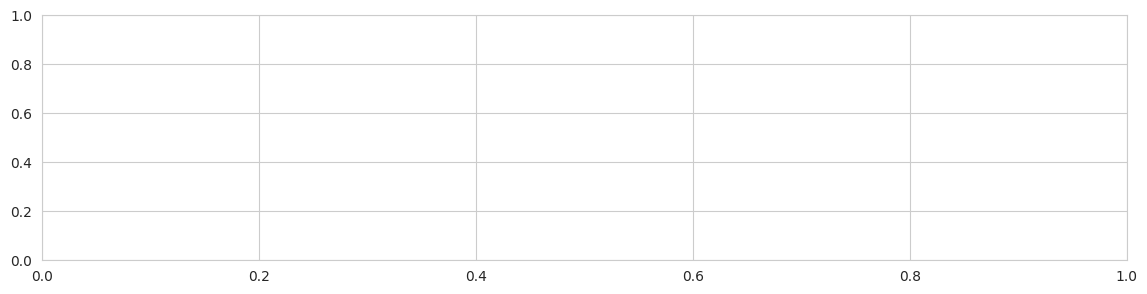

In [2]:
# Set up the plotting style
sns.set_style('whitegrid')

plt.figure(figsize=(14, 7))

# Plot Soil Moisture
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
sns.lineplot(x='Timestamp', y='Soil_Moisture', data=df)
plt.title('Soil Moisture Over Time')
plt.ylabel('Soil Moisture (%)')
plt.xlabel('') # Remove x-label for the top plot for cleaner look

# Plot Soil Temperature
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
sns.lineplot(x='Timestamp', y='Soil_Temperature', data=df, color='orange')
plt.title('Soil Temperature Over Time')
plt.ylabel('Soil Temperature (°C)')
plt.xlabel('Timestamp')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

plt.figure(figsize=(14, 4))
# Plot Ambient Temperature
sns.lineplot(x='Timestamp', y='Ambient_Temperature', data=df, color='red')
plt.title('Ambient Temperature Over Time')
plt.ylabel('Ambient Temperature (°C)')
plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()

### Correlation Matrix

Let's calculate the correlation matrix to understand the linear relationships between the different sensor variables (Soil Moisture, Soil Temperature, and Ambient Temperature).

,Soil_Moisture,Soil_Temperature,Ambient_Temperature
Soil_Moisture,1.000000,-0.114975,-0.206451
Soil_Temperature,-0.114975,1.000000,0.062548
Ambient_Temperature,-0.206451,0.062548,1.000000


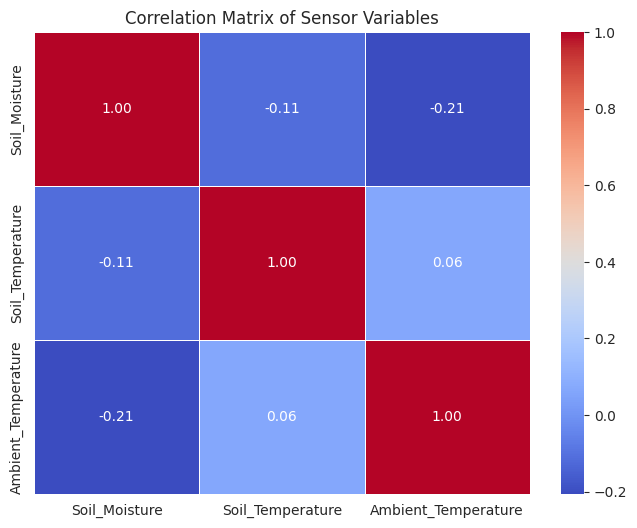

In [4]:
# Calculate the correlation matrix
correlation_matrix = df[['Soil_Moisture', 'Soil_Temperature', 'Ambient_Temperature']].corr()

# Display the correlation matrix
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Sensor Variables')
plt.show()

### Daily Averages of Sensor Variables

To understand the daily patterns, let's calculate the average of each sensor variable for each day and visualize their trends.

In [5]:
# Extract the date part from the Timestamp for daily aggregation
df['Date'] = df['Timestamp'].dt.date

# Calculate daily averages for each sensor variable
daily_averages = df.groupby('Date')[['Soil_Moisture', 'Soil_Temperature', 'Ambient_Temperature']].mean().reset_index()

# Display the daily averages
print("Daily Averages of Sensor Variables:")
display(daily_averages.head())


Daily Averages of Sensor Variables:


,Date,Soil_Moisture,Soil_Temperature,Ambient_Temperature
0,2023-01-01,58.669130,25.615741,17.967494
1,2023-01-02,54.742227,20.776613,14.765015
2,2023-01-03,47.077475,22.162792,17.738980
3,2023-01-04,48.914435,20.154218,18.212165
4,2023-01-05,30.845647,31.293915,28.824746


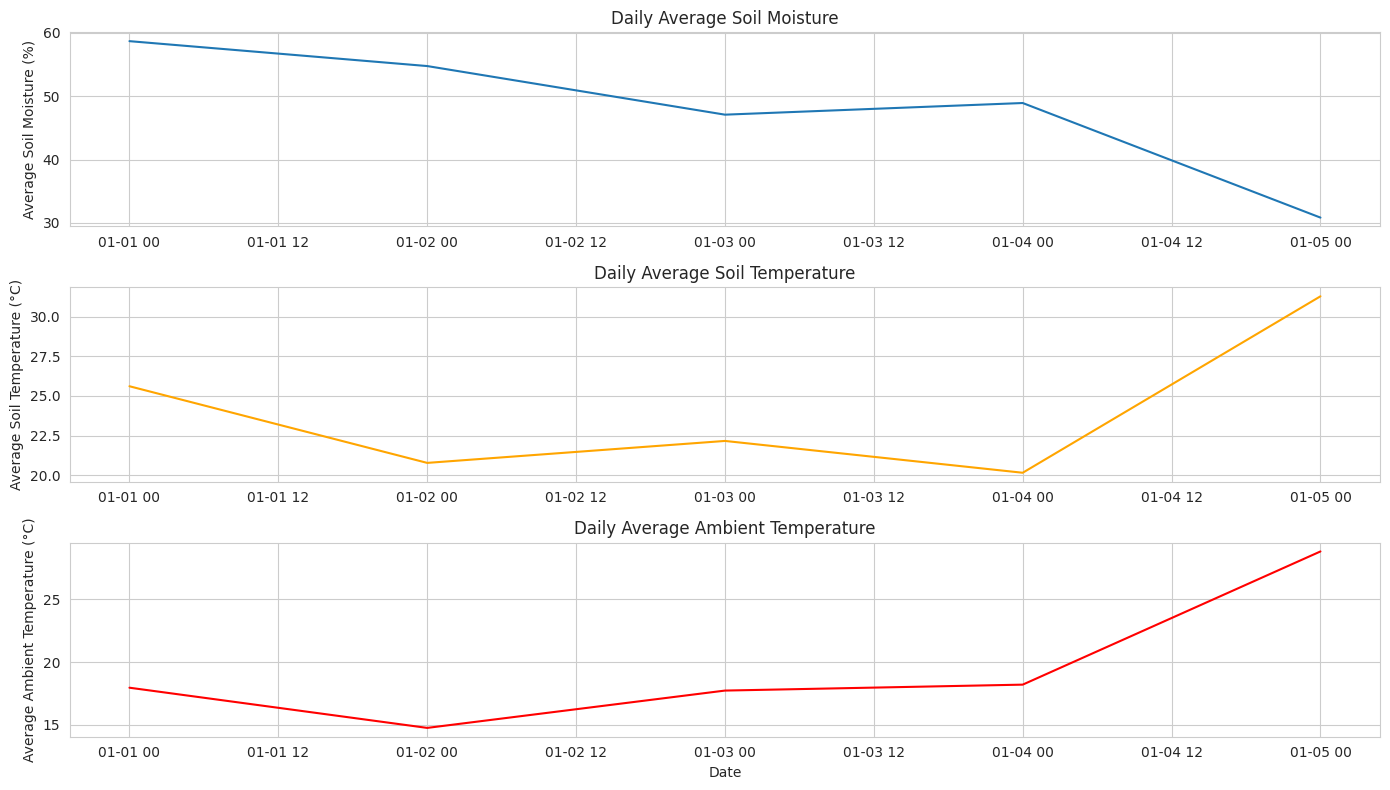

In [6]:
plt.figure(figsize=(14, 8))

# Plot daily average Soil Moisture
plt.subplot(3, 1, 1)
sns.lineplot(x='Date', y='Soil_Moisture', data=daily_averages)
plt.title('Daily Average Soil Moisture')
plt.ylabel('Average Soil Moisture (%)')
plt.xlabel('')

# Plot daily average Soil Temperature
plt.subplot(3, 1, 2)
sns.lineplot(x='Date', y='Soil_Temperature', data=daily_averages, color='orange')
plt.title('Daily Average Soil Temperature')
plt.ylabel('Average Soil Temperature (°C)')
plt.xlabel('')

# Plot daily average Ambient Temperature
plt.subplot(3, 1, 3)
sns.lineplot(x='Date', y='Ambient_Temperature', data=daily_averages, color='red')
plt.title('Daily Average Ambient Temperature')
plt.ylabel('Average Ambient Temperature (°C)')
plt.xlabel('Date')

plt.tight_layout()
plt.show()
